# Workload, rest, and subsequent appearance effectiveness

Explore whether acute and season-to-date workload are associated with performance in subsequent relief appearances. `pitcher_appearances` describes what happened during an appearance; `pitcher_workload` describes workload before it. This notebook relates the two without creating another production model.

## 1. Setup and parameters

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

from crooked_numbers_analytics.appearances import (
    create_pitcher_appearances_view,
)
from crooked_numbers_analytics.db import open_database
from crooked_numbers_analytics.workload import create_pitcher_workload_view

con = open_database()

In [2]:
seasons = [2021, 2022, 2023, 2024, 2025, 2026]
inspection_season = 2024
inspection_team = "MIL"
inspection_pitcher_id = 642207  # Devin Williams

## 2. Build appearance and workload views

Pitch-level data is aggregated in DuckDB before any small result is converted to pandas. The session-local research table below keeps repeated exploration at appearance grain.

In [3]:
create_pitcher_appearances_view(con, seasons=seasons)
create_pitcher_workload_view(con)

## 3. Prior-only pitcher baselines

Baselines use appearances earlier in the same season, ordered by `game_date, game_pk`. Rate baselines are denominator-weighted: total whiffs divided by total swings, for example. Current relief appearances are filtered only after prior workload from both starts and relief appearances has been accumulated.

In [4]:
con.execute(
    """
    CREATE OR REPLACE TEMP TABLE relief_effectiveness AS
    WITH prior_totals AS (
        SELECT
            *,
            min(game_date) OVER (PARTITION BY pitcher_id, season)
                AS first_appearance_date,
            sum(fastball_pitches * avg_fastball_velocity) OVER prior
                AS prior_fastball_velocity_sum,
            sum(fastball_pitches) OVER prior AS prior_fastballs,
            sum(strikes) OVER prior AS prior_strikes,
            sum(pitch_count) OVER prior AS prior_pitches,
            sum(whiffs) OVER prior AS prior_whiffs,
            sum(swings) OVER prior AS prior_swings,
            sum(csw) OVER prior AS prior_csw
        FROM pitcher_workload
        WINDOW prior AS (
            PARTITION BY pitcher_id, season
            ORDER BY game_date, game_pk
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
        )
    ),
    with_baselines AS (
        SELECT
            *,
            prior_fastball_velocity_sum / nullif(prior_fastballs, 0)
                AS prior_fastball_velocity,
            prior_strikes / nullif(prior_pitches, 0)::DOUBLE
                AS prior_strike_rate,
            prior_whiffs / nullif(prior_swings, 0)::DOUBLE
                AS prior_whiff_rate,
            prior_csw / nullif(prior_pitches, 0)::DOUBLE
                AS prior_csw_rate
        FROM prior_totals
    )
    SELECT
        *,
        month(game_date) AS month,
        date_diff('day', first_appearance_date, game_date)
            AS days_since_first_appearance,
        avg_fastball_velocity - prior_fastball_velocity
            AS fastball_velocity_delta,
        strike_rate - prior_strike_rate AS strike_rate_delta,
        whiff_rate - prior_whiff_rate AS whiff_rate_delta,
        csw_rate - prior_csw_rate AS csw_rate_delta
    FROM with_baselines
    WHERE NOT is_start
    """
)

In [5]:
con.sql(
    """
    SELECT
        COUNT(*) AS relief_appearances,
        COUNT(DISTINCT pitcher_id) AS pitchers,
        MIN(game_date) AS first_date,
        MAX(game_date) AS last_date,
        COUNT(*) FILTER (WHERE fastball_velocity_delta IS NOT NULL)
            AS velocity_delta_sample
    FROM relief_effectiveness
    """
).df()

,relief_appearances,pitchers,first_date,last_date,velocity_delta_sample
0,96254,1817,2021-04-01,2026-09-27,72509


## A. Does short-term rest correlate with appearance quality?

Raw rates below are aggregated from their numerators and denominators rather than averaging appearance percentages. Delta columns compare each appearance with that pitcher's prior-only season baseline.

In [6]:
rest_summary = con.sql(
    """
    WITH labeled AS (
        SELECT
            *,
            CASE
                WHEN days_rest = 0 THEN '0'
                WHEN days_rest = 1 THEN '1'
                WHEN days_rest = 2 THEN '2'
                ELSE '3+'
            END AS rest_group
        FROM relief_effectiveness
        WHERE days_rest IS NOT NULL
    )
    SELECT
        rest_group,
        COUNT(*) AS appearances,
        COUNT(DISTINCT pitcher_id) AS pitchers,
        sum(avg_fastball_velocity * fastball_pitches)
            / nullif(sum(fastball_pitches), 0) AS fastball_velocity,
        sum(strikes) / sum(pitch_count)::DOUBLE AS strike_rate,
        sum(whiffs) / nullif(sum(swings), 0)::DOUBLE AS whiff_rate,
        sum(csw) / sum(pitch_count)::DOUBLE AS csw_rate,
        sum(hard_hit_count) / nullif(sum(exit_velocity_balls), 0)::DOUBLE
            AS hard_hit_rate,
        avg(fastball_velocity_delta) AS avg_velocity_delta,
        avg(whiff_rate_delta) AS avg_whiff_rate_delta
    FROM labeled
    GROUP BY rest_group
    ORDER BY CASE rest_group WHEN '0' THEN 0 WHEN '1' THEN 1
                             WHEN '2' THEN 2 ELSE 3 END
    """
).df()
rest_summary

,rest_group,appearances,pitchers,fastball_velocity,strike_rate,whiff_rate,csw_rate,hard_hit_rate,avg_velocity_delta,avg_whiff_rate_delta
0,0,15840,1041,94.894291,0.636451,0.250997,0.280852,0.380343,0.004414,-0.011071
1,1,26127,1165,94.891019,0.635166,0.250229,0.280758,0.385737,0.121204,-0.006604
2,2,20871,1197,94.852511,0.635497,0.251076,0.282150,0.379675,0.154884,-0.004049
3,3+,31970,1588,94.474904,0.633455,0.237262,0.273911,0.385766,0.199420,-0.001883


## B. Does recent pitch workload correlate with appearance quality?

These buckets are exploratory notebook labels, not reusable workload definitions. The table retains previous-day and seven-day averages alongside the three-day grouping.

In [7]:
recent_pitch_summary = con.sql(
    """
    WITH labeled AS (
        SELECT
            *,
            CASE
                WHEN pitches_last_3_days = 0 THEN '0'
                WHEN pitches_last_3_days < 20 THEN '1-19'
                WHEN pitches_last_3_days < 40 THEN '20-39'
                WHEN pitches_last_3_days < 60 THEN '40-59'
                ELSE '60+'
            END AS pitch_group
        FROM relief_effectiveness
    )
    SELECT
        pitch_group, COUNT(*) AS appearances,
        COUNT(DISTINCT pitcher_id) AS pitchers,
        round(avg(pitches_previous_day), 1) AS avg_previous_day_pitches,
        round(avg(pitches_last_7_days), 1) AS avg_last_7_day_pitches,
        avg(fastball_velocity_delta) AS avg_velocity_delta,
        avg(strike_rate_delta) AS avg_strike_rate_delta,
        avg(whiff_rate_delta) AS avg_whiff_rate_delta,
        avg(csw_rate_delta) AS avg_csw_rate_delta
    FROM labeled
    GROUP BY pitch_group
    ORDER BY min(pitches_last_3_days)
    """
).df()
recent_pitch_summary

,pitch_group,appearances,pitchers,avg_previous_day_pitches,avg_last_7_day_pitches,avg_velocity_delta,avg_strike_rate_delta,avg_whiff_rate_delta,avg_csw_rate_delta
0,0,33416,1810,0.0,23.9,0.199420,0.013083,-0.001883,0.003175
1,1-19,37131,1200,3.0,34.8,0.126884,0.012836,-0.007743,0.000304
2,20-39,23722,1193,4.4,45.9,0.070509,0.016921,-0.005691,0.002846
3,40-59,1895,715,6.3,60.0,0.088658,0.017330,-0.005274,0.004401
4,60+,90,80,7.4,82.7,0.184557,0.024109,0.001112,0.011102


## C. Do recent ups add information beyond pitch count?

Compare up counts only within similar three-day pitch totals. Any differences remain descriptive associations; this does not isolate an effect caused by ups.

In [8]:
ups_summary = con.sql(
    """
    WITH labeled AS (
        SELECT
            *,
            (10 * floor(pitches_last_3_days / 10))::BIGINT AS pitch_floor,
            CASE WHEN ups_last_3_days >= 3 THEN '3+'
                 ELSE ups_last_3_days::VARCHAR END AS ups_group
        FROM relief_effectiveness
        WHERE pitches_last_3_days BETWEEN 10 AND 49
    )
    SELECT
        printf('%d-%d', pitch_floor, pitch_floor + 9) AS pitch_group,
        ups_group, COUNT(*) AS appearances,
        avg(fastball_velocity_delta) AS avg_velocity_delta,
        avg(whiff_rate_delta) AS avg_whiff_rate_delta
    FROM labeled
    GROUP BY pitch_floor, ups_group
    HAVING COUNT(*) >= 30
    ORDER BY pitch_floor, ups_group
    """
).df()
ups_summary

,pitch_group,ups_group,appearances,avg_velocity_delta,avg_whiff_rate_delta
0,10-19,1,24349,0.105095,-0.007794
1,10-19,2,5093,0.159523,-0.006828
2,10-19,3+,156,0.102050,-0.024087
3,20-29,1,7657,0.040962,-0.005073
4,20-29,2,8652,0.099341,-0.006608
5,20-29,3+,944,0.164830,-0.004498
6,30-39,1,727,-0.015453,-0.001406
7,30-39,2,4341,0.043839,-0.006267
8,30-39,3+,1401,0.132492,-0.004643
9,40-49,2,850,0.124675,0.002412


## D. Does season-to-date workload correlate with performance?

Cumulative workload can move with calendar time, role, health, and selection. The correlations and buckets below are descriptive and do not imply that accumulated innings or pitches caused a change.

In [9]:
con.sql(
    """
    SELECT
        corr(season_appearance_number, fastball_velocity_delta)
            AS appearance_number_velocity_correlation,
        corr(season_pitches_before, fastball_velocity_delta)
            AS season_pitches_velocity_correlation,
        corr(season_ip_before, fastball_velocity_delta)
            AS season_ip_velocity_correlation,
        corr(season_ups_before, fastball_velocity_delta)
            AS season_ups_velocity_correlation,
        corr(season_pitches_before, whiff_rate_delta)
            AS season_pitches_whiff_correlation,
        COUNT(*) AS appearances
    FROM relief_effectiveness
    """
).df()

,appearance_number_velocity_correlation,season_pitches_velocity_correlation,season_ip_velocity_correlation,season_ups_velocity_correlation,season_pitches_whiff_correlation,appearances
0,0.015912,0.067103,0.068883,0.063774,0.01773,96254


In [10]:
season_ip_summary = con.sql(
    """
    SELECT
        10 * floor(season_ip_before / 10) AS season_ip_floor,
        COUNT(*) AS appearances,
        COUNT(DISTINCT pitcher_id) AS pitchers,
        avg(season_appearance_number) AS avg_appearance_number,
        avg(season_pitches_before) AS avg_season_pitches,
        avg(season_ups_before) AS avg_season_ups,
        avg(fastball_velocity_delta) AS avg_velocity_delta,
        avg(whiff_rate_delta) AS avg_whiff_rate_delta
    FROM relief_effectiveness
    GROUP BY season_ip_floor
    HAVING COUNT(*) >= 100
    ORDER BY season_ip_floor
    """
).df()
season_ip_summary

,season_ip_floor,appearances,pitchers,avg_appearance_number,avg_season_pitches,avg_season_ups,avg_velocity_delta,avg_whiff_rate_delta
0,0.0,26196,1697,4.991678,72.269850,5.197397,-0.013286,-0.009057
1,10.0,19087,1111,14.744224,245.572065,17.919264,0.165825,-0.003776
2,20.0,15509,910,24.355664,411.137275,30.127216,0.221129,-0.007443
3,30.0,12614,750,34.026003,574.657682,42.213176,0.203754,-0.006866
4,40.0,10127,616,43.530759,738.677298,54.109016,0.133000,-0.003453
5,50.0,7248,521,51.753863,896.805188,65.238825,0.113918,0.000690
6,60.0,3432,405,55.814977,1039.636946,75.509615,0.142306,-0.000984
7,70.0,999,202,48.928929,1192.442442,84.923924,0.330469,0.002756
8,80.0,355,98,39.157746,1375.867606,94.352113,0.511424,0.001717
9,90.0,189,73,31.264550,1579.645503,103.042328,0.448094,0.014658


## E. Season progression

Month and days since the first appearance provide calendar context. Performance changing later in a season is not equivalent to performance changing because workload accumulated.

In [11]:
con.sql(
    """
    SELECT
        month, COUNT(*) AS appearances,
        COUNT(DISTINCT pitcher_id) AS pitchers,
        avg(days_since_first_appearance) AS avg_days_into_pitcher_season,
        avg(season_ip_before) AS avg_season_ip_before,
        avg(fastball_velocity_delta) AS avg_velocity_delta,
        avg(whiff_rate_delta) AS avg_whiff_rate_delta
    FROM relief_effectiveness
    GROUP BY month
    ORDER BY month
    """
).df()

,month,appearances,pitchers,avg_days_into_pitcher_season,avg_season_ip_before,avg_velocity_delta,avg_whiff_rate_delta
0,3,1536,515,1.278646,0.510417,-0.237818,0.000227
1,4,15046,1076,14.126678,5.389738,-0.001051,-0.011737
2,5,16042,1125,39.034534,14.118169,0.183109,-0.007482
3,6,15442,1142,64.159241,22.307905,0.253962,-0.006259
4,7,14737,1160,89.633847,29.929904,0.194381,-0.005536
5,8,16307,1180,113.680567,36.989616,0.117887,-0.002908
6,9,16167,1204,136.873570,44.217686,0.076052,-0.000064
7,10,977,489,147.236438,47.773115,0.031464,0.012099


## 4. Compact exploratory plots

Labels include appearance sample sizes. These plots summarize associations and are not adjusted estimates.

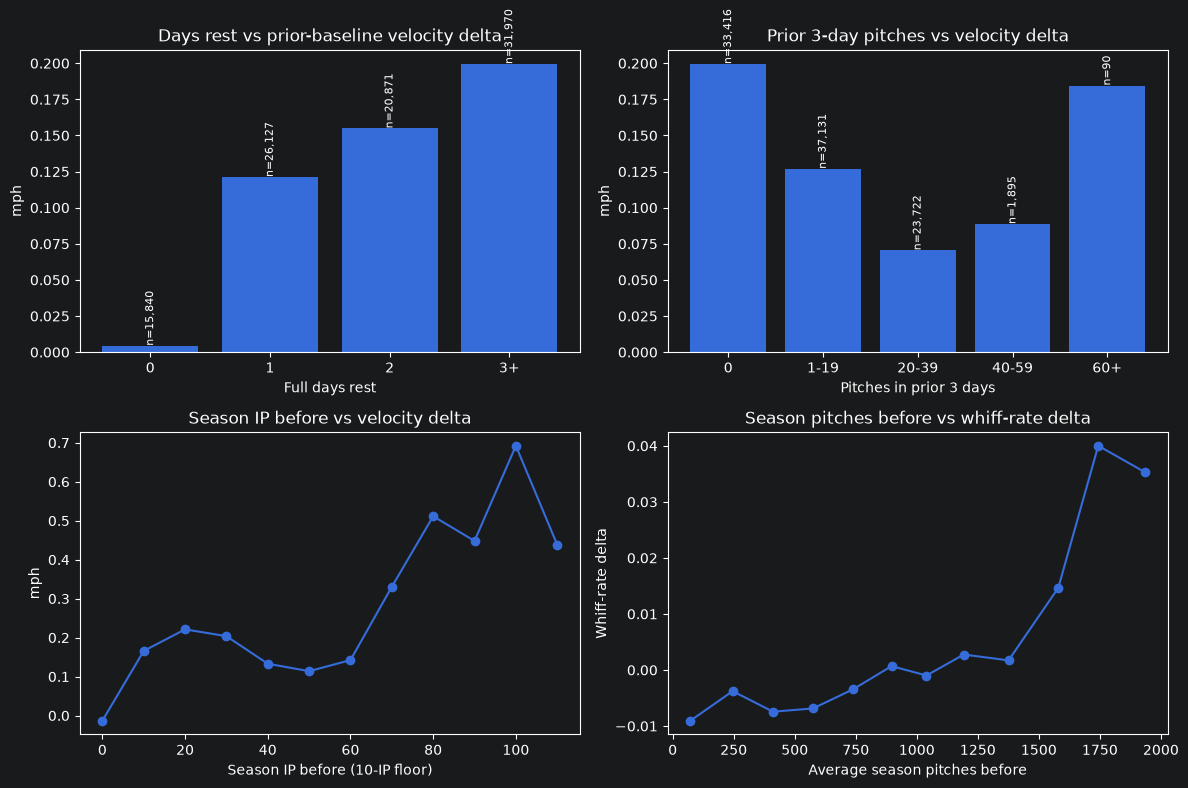

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].bar(
    rest_summary['rest_group'], rest_summary['avg_velocity_delta']
)
axes[0, 0].set_title('Days rest vs prior-baseline velocity delta')
axes[0, 0].set_xlabel('Full days rest')
axes[0, 0].set_ylabel('mph')

axes[0, 1].bar(
    recent_pitch_summary['pitch_group'],
    recent_pitch_summary['avg_velocity_delta'],
)
axes[0, 1].set_title('Prior 3-day pitches vs velocity delta')
axes[0, 1].set_xlabel('Pitches in prior 3 days')
axes[0, 1].set_ylabel('mph')

axes[1, 0].plot(
    season_ip_summary['season_ip_floor'],
    season_ip_summary['avg_velocity_delta'],
    marker='o',
)
axes[1, 0].set_title('Season IP before vs velocity delta')
axes[1, 0].set_xlabel('Season IP before (10-IP floor)')
axes[1, 0].set_ylabel('mph')

axes[1, 1].plot(
    season_ip_summary['avg_season_pitches'],
    season_ip_summary['avg_whiff_rate_delta'],
    marker='o',
)
axes[1, 1].set_title('Season pitches before vs whiff-rate delta')
axes[1, 1].set_xlabel('Average season pitches before')
axes[1, 1].set_ylabel('Whiff-rate delta')

for axis, frame in [
    (axes[0, 0], rest_summary),
    (axes[0, 1], recent_pitch_summary),
]:
    for patch, sample_size in zip(axis.patches, frame['appearances'], strict=True):
        axis.annotate(
            f'n={sample_size:,}',
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha='center', va='bottom', fontsize=8, rotation=90,
        )

fig.tight_layout()

## 5. Individual pitcher exploration

Inspect pitchers only after confirming a useful sample. Variation can motivate later research, but these summaries do not estimate an ideal rest period.

In [13]:
con.execute(
    """
    SELECT
        pitcher_id, any_value(pitcher_name) AS pitcher_name,
        COUNT(*) AS relief_appearances,
        COUNT(*) FILTER (WHERE fastball_velocity_delta IS NOT NULL)
            AS velocity_samples
    FROM relief_effectiveness
    WHERE season = ? AND pitching_team = ?
    GROUP BY pitcher_id
    HAVING COUNT(*) >= 20
    ORDER BY relief_appearances DESC
    """,
    [inspection_season, inspection_team],
).df()

,pitcher_id,pitcher_name,relief_appearances,velocity_samples
0,606303,"Payamps, Joel",68,65
1,571948,"Milner, Hoby",60,54
2,665625,"Peguero, Elvis",52,0
3,657649,"Koenig, Jared",49,7
4,656730,"Megill, Trevor",48,47
5,663542,"Hudson, Bryan",43,42
6,669060,"Wilson, Bryse",25,23
7,642207,"Williams, Devin",22,21


In [14]:
con.execute(
    """
    SELECT
        game_date, pitching_team, days_rest,
        pitches_last_3_days, ups_last_3_days,
        season_appearance_number, season_ip_before,
        avg_fastball_velocity, fastball_velocity_delta,
        strike_rate, strike_rate_delta,
        whiff_rate, whiff_rate_delta, csw_rate, csw_rate_delta,
        exit_velocity_balls, hard_hit_rate
    FROM relief_effectiveness
    WHERE season = ? AND pitcher_id = ?
    ORDER BY game_date, game_pk
    """,
    [inspection_season, inspection_pitcher_id],
).df()

,game_date,pitching_team,days_rest,pitches_last_3_days,ups_last_3_days,season_appearance_number,season_ip_before,avg_fastball_velocity,fastball_velocity_delta,strike_rate,strike_rate_delta,whiff_rate,whiff_rate_delta,csw_rate,csw_rate_delta,exit_velocity_balls,hard_hit_rate
0,2024-07-28,MIL,301,0.0,0.0,1,0.000000,95.978571,NaN,0.541667,NaN,0.200000,NaN,0.208333,NaN,3,0.333333
1,2024-08-04,MIL,6,0.0,0.0,2,1.000000,94.511111,-1.467460,0.529412,-0.012255,0.333333,0.133333,0.294118,0.085784,3,0.000000
2,2024-08-07,MIL,2,17.0,1.0,3,2.000000,95.030000,-0.374348,0.769231,0.232645,0.400000,0.150000,0.538462,0.294559,1,1.000000
3,2024-08-10,MIL,2,13.0,1.0,4,3.000000,94.925000,-0.365909,0.500000,-0.092593,0.600000,0.314286,0.388889,0.074074,0,NaN
4,2024-08-14,MIL,3,0.0,0.0,5,4.000000,94.760000,-0.433333,1.000000,0.430556,0.250000,-0.096154,0.571429,0.238095,2,0.500000
5,2024-08-15,MIL,0,7.0,1.0,6,5.000000,95.170000,0.020000,0.562500,-0.045095,0.222222,-0.111111,0.125000,-0.229430,1,0.000000
6,2024-08-17,MIL,1,23.0,2.0,7,6.000000,95.225000,0.071667,0.500000,-0.100000,0.400000,0.092308,0.200000,-0.115789,3,0.000000
7,2024-08-20,MIL,2,10.0,1.0,8,7.000000,94.845455,-0.312358,0.571429,-0.019048,0.555556,0.237374,0.380952,0.076190,2,0.000000
8,2024-08-21,MIL,0,21.0,1.0,9,8.000000,93.600000,-1.512000,0.387097,-0.200205,0.444444,0.085954,0.225806,-0.091654,1,0.000000
9,2024-08-28,MIL,6,0.0,0.0,10,8.666667,93.585714,-1.317734,0.636364,0.088593,0.285714,-0.085253,0.181818,-0.117545,2,0.500000


## Interpretation: association is not causation

Managers do not assign workload or rest randomly. Pitcher identity and quality, age, injury or health, bullpen role, team, manager, leverage, opponent, season, calendar time, weather, recent performance, and roster availability can all confound these comparisons. Selection effects also matter: a pitcher must remain healthy and effective enough to keep appearing.

It is appropriate to say **pitchers with a given observed workload performed differently in this sample**. These descriptive tables and plots do not establish that the workload caused the difference, identify an ideal rest period, or support an availability rule.